# P2P loan or Payment

We have Alice and Bob. Alice owes to Bob 30. Alice has 20 in the bank and Bob is happy to accept it.
There is also Charlie who owes 20 to Alice, but has no money. Bob is willing to extend a P2P loan of 20 to Charlie.

The question is, how does this situation play out in an MTCS scenario? We want to give preference to the network's internal liquidity. In our case this is a P2P loan.

In this experiment we use weights on the network edges to give a P2P loan preference over a bank payment.

We use the [Multilateral Settlement Network](docs/Multilateral_Settlement_Network.md) model and notation to examine this case.

## Input data

See the data describing this situation in more detail [here](data/p2p_or_pay.csv)

## Import the functions for modeling

In [1]:
import sys, os
from pathlib import Path

# Find repo root and set it as working directory so data/ and utils/ paths resolve correctly
root = Path(os.getcwd()).resolve()
if not (root / 'utils').is_dir():
    root = root.parent
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.graph_operations import add, sub, pos, neg, tra
from utils.graph_visualization import graph_print, graph_draw
from utils.graph_max_flow_solvers import max_flow_solver
from utils.graph_read_write import read_graph_from_csv, split_graph_by_edge_data
import networkx as nx

## Reading the network edges data with the weights for solver priorities

We start by reading the data and splitting it into two networks: obligations $g$ and commitments $\overline{g}$.
The data we use for this experiment includes the "weight" for each obligation or commitment.
The weights are set as follows:
* $1$ for obligations
* $0$ for P2P commitments
* $-1$ for outside money commitments

In [2]:
g = read_graph_from_csv("data/p2p_or_pay.csv")
g, g_overline = split_graph_by_edge_data(g, "o/c", "o")

order = ["alice", "bob", "charlie", "$"]

print('--- Obligations ---')
graph_print(g, order=order)

print('--- Commitments ---')
graph_print(g_overline, order=order)

--- Obligations ---
         alice  bob  charlie  $
alice        0   30        0  0
bob          0    0        0  0
charlie     20    0        0  0
$           20    0        0  0

--- Commitments ---
         alice  bob  charlie   $
alice        0    0        0   0
bob          0    0       20  20
charlie      0    0        0   0
$            0    0        0   0



Then we join the networks to form a settlement network $p$.

--- Settlement network ---
         alice  bob  charlie   $
alice        0   30        0   0
bob          0    0       20  20
charlie     20    0        0   0
$           20    0        0   0



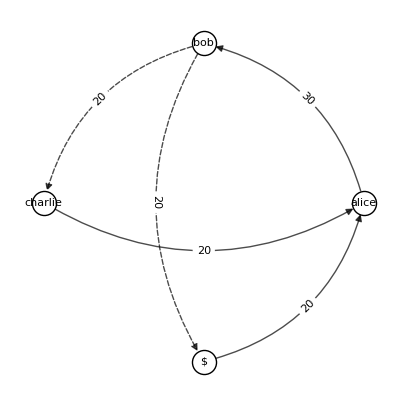

In [3]:
p = add(g, g_overline)

print('--- Settlement network ---')
graph_print(p, order=order)

graph_draw(p)

Let's print the edges with weights to check if the priorities with weight are set properly.

In [4]:
for edge in p.edges(data=True):
    print(edge)

('alice', 'bob', {'capacity': 30, 'o/c': 'o', 'weight': 1})
('bob', 'charlie', {'capacity': 20, 'o/c': 'c', 'weight': 0})
('bob', '$', {'capacity': 20, 'o/c': 'c', 'weight': -1})
('charlie', 'alice', {'capacity': 20, 'o/c': 'o', 'weight': 1})
('$', 'alice', {'capacity': 20, 'o/c': 'o', 'weight': 1})


Using a solver, we try to find a solution - a cyclic structure $\hat{p}$ - within the settlement network

--- Settlement Flow ---
         alice  bob  charlie   $
alice        0   30        0   0
bob          0    0       20  10
charlie     20    0        0   0
$           10    0        0   0



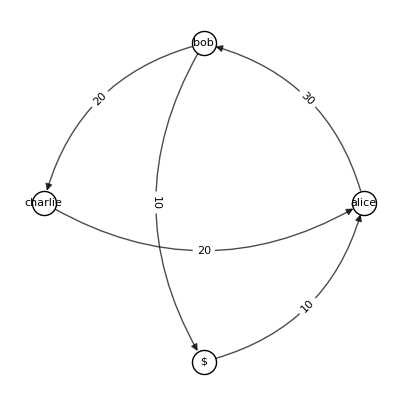

In [5]:
p_hat = max_flow_solver(p)

print('--- Settlement Flow ---')
graph_print(p_hat, order=order)

graph_draw(p_hat)

The settlement flow traverses both the obligation and the commitment networks.
The settlement flow has to be a cyclic structure. We can see that each node is perfectly balanced, as the amounts coming in equal the amounts going out.

We also see that Bob offering a P2P loan was preferred to the outside money solution.
The P2P loan offer of 20 was used in full.
Only part of outside money available for payment was used.

--- Remaining and new obligations after Settlement ---
         alice  bob  charlie  $
alice        0    0        0  0
bob          0    0        0  0
charlie      0   20        0  0
$           10   10        0  0



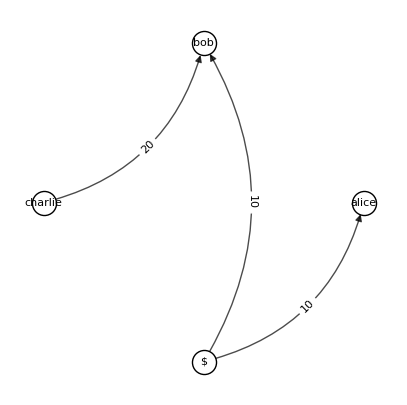

In [6]:
g_prime = add(pos(sub(g, p_hat)), tra(neg(sub(g, p_hat))))

print('--- Remaining and new obligations after Settlement ---')
graph_print(g_prime, order=order)

graph_draw(g_prime)

The result of the settlement is that Alice no longer owes Bob. She still has 10 in her bank account.
Bob also has 10 in a bank account. In addition to this he is expecting a debt repayment of 10 from Charlie.

We started with an indebtedness within the community of 30. This was the debt of Alice to Bob.
We ended up with an indebtedness within the community of 20. This is the result of prioritizing the P2P loan.

The question is, Is this really what we want?

## Turning the priorities upside down

Let's change the weight of the commitments to see what happens.

In [7]:
p["bob"]["charlie"]["weight"] = -1
p["bob"]["$"]["weight"] = 0

Let's do the settlement again with new priorities.

--- Settlement Flow ---
         alice  bob  charlie   $
alice        0   30        0   0
bob          0    0       10  20
charlie     10    0        0   0
$           20    0        0   0



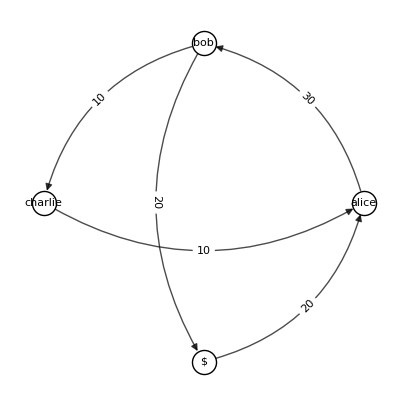

In [8]:
p_hat = max_flow_solver(p)

print('--- Settlement Flow ---')
graph_print(p_hat, order=order)

graph_draw(p_hat)

We can see that the settlement flow is now leaning towards payment.

We complete the operation to see the final result.

--- Remaining and new obligations after Settlement ---
         alice  bob  charlie  $
alice        0    0        0  0
bob          0    0        0  0
charlie     10   10        0  0
$            0   20        0  0



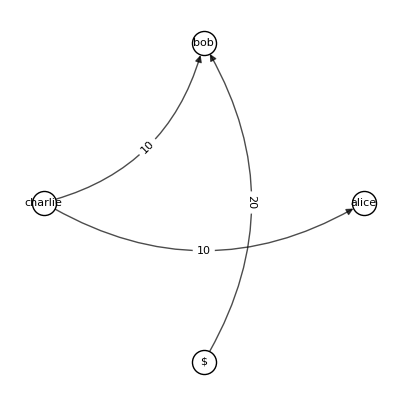

In [9]:
g_prime = add(pos(sub(g, p_hat)), tra(neg(sub(g, p_hat))))

print('--- Remaining and new obligations after Settlement ---')
graph_print(g_prime, order=order)

graph_draw(g_prime)

We can observe that the mutual indebtedness within the network has not changed. It is still 20.

## Why we can't change the remaining mutual indebtedness

Looking at [Mathematical Foundations for Balancing the Payment System in the Trade Credit Market](https://doi.org/10.3390/jrfm14090452) Theorem 4 - Subtracting a cycle from the obligation network does not change the vector of net positions 𝐛, you can see that the settlement can't change the net positions of the participants within the network. This is why the mutual indebtedness of the result remains the same.

## True result of prioritization

Preferring the P2P over outside money did not change the amount of internal indebtedness. What changed is the distribution. In our case we can see that, by prioritizing P2P loans, Alice was able to retain or "save" money in her bank account. Bob therefore ended up with less money (10) and a larger new debt from Charlie (20). Since the debt from Charlie is less liquid that money in the bank, Bob is worse off in the P2P preference scenario. The opposite is true for Alice.

The question is: is it OK that Alice "the debtor of 30" is better off than Bob "the creditor of 30"?